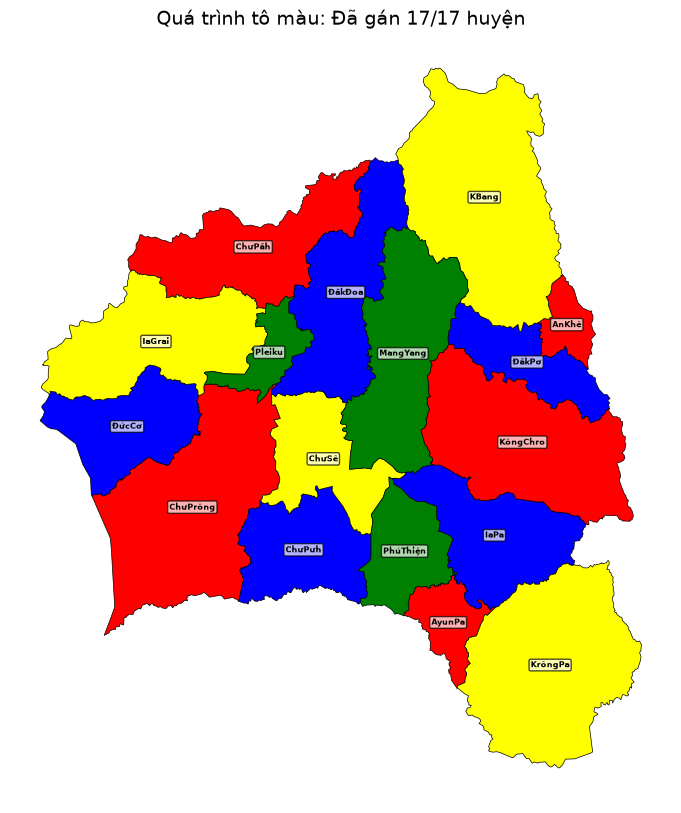

Hoàn tất!


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# LOAD VÀ XỬ LÝ DỮ LIỆU
gdf = gpd.read_file("C:/Users/ADM/Downloads/gadm41_VNM_2.json")
gia_lai_map = gdf[gdf['NAME_1'] == 'GiaLai'].copy()

# Cấu hình CRS để vẽ bản đồ
if gia_lai_map.crs is None:
    gia_lai_map.set_crs(epsg=4326, inplace=True)
gia_lai_map = gia_lai_map.to_crs(epsg=3857)

# Xây dựng danh sách kề
adj_list = {}
for i, row in gia_lai_map.iterrows():
    neighbors = gia_lai_map[gia_lai_map.geometry.distance(row.geometry) < 0.001]['NAME_2'].tolist()
    adj_list[row['NAME_2']] = [n for n in neighbors if n != row['NAME_2']]

# THUẬT TOÁN BACKTRACKING KÈM HIỆU ỨNG VẼ
assignment = {}
districts = gia_lai_map['NAME_2'].tolist()
colors = ['red', 'blue', 'yellow', 'green']

def draw_step(step_assignment):
    """Hàm vẽ trạng thái hiện tại của bản đồ với nhãn tên"""
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Vẽ các vùng với màu đã gán
    current_colors = gia_lai_map['NAME_2'].map(step_assignment).fillna('lightgrey')
    gia_lai_map.plot(ax=ax, color=current_colors, edgecolor='black', linewidth=0.5)
    
    # VẼ TÊN HUYỆN LÊN BẢN ĐỒ
    for idx, row in gia_lai_map.iterrows():
        # Lấy tọa độ trung tâm
        centroid = row['geometry'].centroid
        
        # Thêm nhãn với định dạng dễ đọc
        plt.annotate(text=row['NAME_2'], 
                     xy=(centroid.x, centroid.y), 
                     ha='center', va='center', 
                     fontsize=6, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)) # Hộp trắng nền chữ

    plt.title(f"Quá trình tô màu: Đã gán {len(step_assignment)}/{len(districts)} huyện", fontsize=14)
    plt.axis('off')
    plt.show()
    time.sleep(0.3)

def backtrack():
    if len(assignment) == len(districts):
        return True
    
    unassigned = [d for d in districts if d not in assignment]
    district = unassigned[0]
    
    for color in colors:
        if is_consistent(district, color):
            assignment[district] = color
            draw_step(assignment) # CẬP NHẬT GIAO DIỆN
            
            if backtrack(): return True
            
            # Nếu quay lui, xóa màu và cập nhật lại bản đồ
            del assignment[district]
            draw_step(assignment)
    return False

def is_consistent(district, color):
    for neighbor in adj_list.get(district, []):
        if neighbor in assignment and assignment[neighbor] == color:
            return False
    return True

# Vẽ bản đồ trắng lúc đầu
draw_step({})
# Bắt đầu thuật toán
backtrack()
print("Hoàn tất!")